## Read Data and Perform Preprocessing

In [12]:
# Step 1: Data Preprocessing
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

# Read the dataset
df = pd.read_csv(r"E:\MS Data Science\Machine Learning\Home Work\SuicideChina.csv")

print("✅ Initial data shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(), "\n")

# ----- a. Handle Missing Values -----
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numeric columns: replace missing with mean
imputer_num = SimpleImputer(strategy='mean')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

# Categorical columns: replace missing with most frequent
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# ----- b. Encoding -----
# Identify which expected columns exist
onehot_cols = [col for col in ['Urban', 'Sex', 'Occupation', 'Method'] if col in df.columns]
ordinal_cols = [col for col in ['Education'] if col in df.columns]
label_col = 'Died' if 'Died' in df.columns else None

# i. One-Hot Encoding for Urban, Sex, Occupation, Method
if onehot_cols:
    df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# ii. Ordinal Encoding for Education
if ordinal_cols:
    ordinal_encoder = OrdinalEncoder()
    df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols])

# iii. Label Encoding for output Died
if label_col:
    label_encoder = LabelEncoder()
    df[label_col] = label_encoder.fit_transform(df[label_col])

print("✅ Preprocessing complete!")
print("New shape:", df.shape)
print(df.head())


✅ Initial data shape: (2571, 11)
Columns: ['Person_ID', 'Hospitalised', 'Urban', 'Year', 'Month', 'Sex', 'Age', 'Education', 'Occupation', 'method', 'Died']
   Person_ID Hospitalised Urban  Year  Month     Sex  Age  Education  \
0          1          yes    no  2010     12  female   39  Secondary   
1          2           no    no  2009      3    male   83    primary   
2          3           no    no  2010      2    male   60    primary   
3          4           no    no  2011      1    male   73    primary   
4          5          yes    no  2009      8    male   51  Secondary   

  Occupation        method Died  
0  household  Other poison   no  
1    farming       Hanging  yes  
2    farming       Hanging  yes  
3    farming       Hanging  yes  
4    farming     Pesticide   no   

✅ Preprocessing complete!
New shape: (2571, 20)
   Person_ID Hospitalised    Year  Month   Age  Education        method  Died  \
0        1.0          yes  2010.0   12.0  39.0        0.0  Other poison    

## Encoding of Non-Numeric Columns

In [13]:
# --- ENCODING OF NON-NUMERIC COLUMNS ---

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

# i. One Hot Encoding for Urban, Sex, Occupation, and Method
onehot_cols = ['Urban', 'Sex', 'Occupation', 'Method']
existing_onehot_cols = [col for col in onehot_cols if col in df.columns]

df = pd.get_dummies(df, columns=existing_onehot_cols, drop_first=True)
print(f"✅ One-Hot Encoding applied to: {existing_onehot_cols}")

# ii. Ordinal Encoding for Education
if 'Education' in df.columns:
    ordinal_encoder = OrdinalEncoder()
    df[['Education']] = ordinal_encoder.fit_transform(df[['Education']])
    print("✅ Ordinal Encoding applied to: Education")

# iii. Label Encoding for output column Died
if 'Died' in df.columns:
    label_encoder = LabelEncoder()
    df['Died'] = label_encoder.fit_transform(df['Died'])
    print("✅ Label Encoding applied to: Died")

print("\nDataFrame after encoding:")
print(df.head())
print("\nDataFrame shape:", df.shape)


✅ One-Hot Encoding applied to: []
✅ Ordinal Encoding applied to: Education
✅ Label Encoding applied to: Died

DataFrame after encoding:
   Person_ID Hospitalised    Year  Month   Age  Education        method  Died  \
0        1.0          yes  2010.0   12.0  39.0        0.0  Other poison     0   
1        2.0           no  2009.0    3.0  83.0        3.0       Hanging     1   
2        3.0           no  2010.0    2.0  60.0        3.0       Hanging     1   
3        4.0           no  2011.0    1.0  73.0        3.0       Hanging     1   
4        5.0          yes  2009.0    8.0  51.0        0.0     Pesticide     0   

   Urban_unknown  Urban_yes  Sex_male  Occupation_farming  \
0          False      False     False               False   
1          False      False      True                True   
2          False      False      True                True   
3          False      False      True                True   
4          False      False      True                True   

   Occupat

## Scatter Plot (Age vs Year)

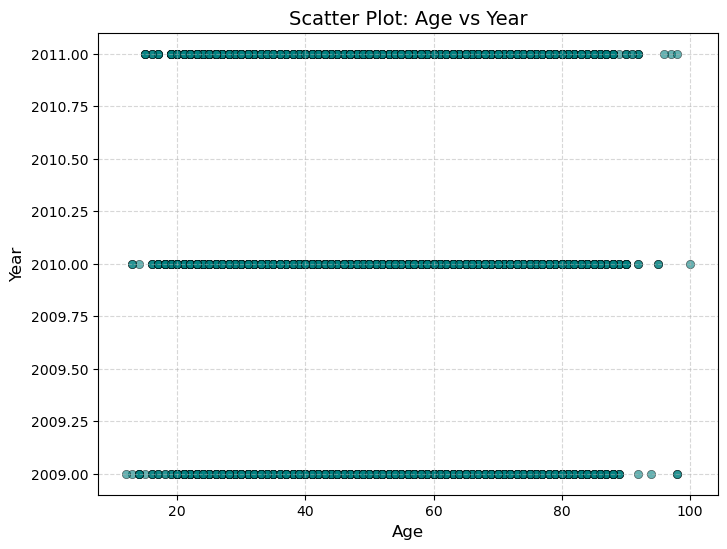

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot between Age and Year
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Year', data=df, alpha=0.6, color='teal', edgecolor='black')

plt.title("Scatter Plot: Age vs Year", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Bar Chart: Suicide Count by Method

In [18]:
df_raw = pd.read_csv(r"E:\MS Data Science\Machine Learning\Home Work\SuicideChina.csv")
print(df_raw.columns.tolist())


['Person_ID', 'Hospitalised', 'Urban', 'Year', 'Month', 'Sex', 'Age', 'Education', 'Occupation', 'method', 'Died']


Columns: ['Person_ID', 'Hospitalised', 'Urban', 'Year', 'Month', 'Sex', 'Age', 'Education', 'Occupation', 'method', 'Died']


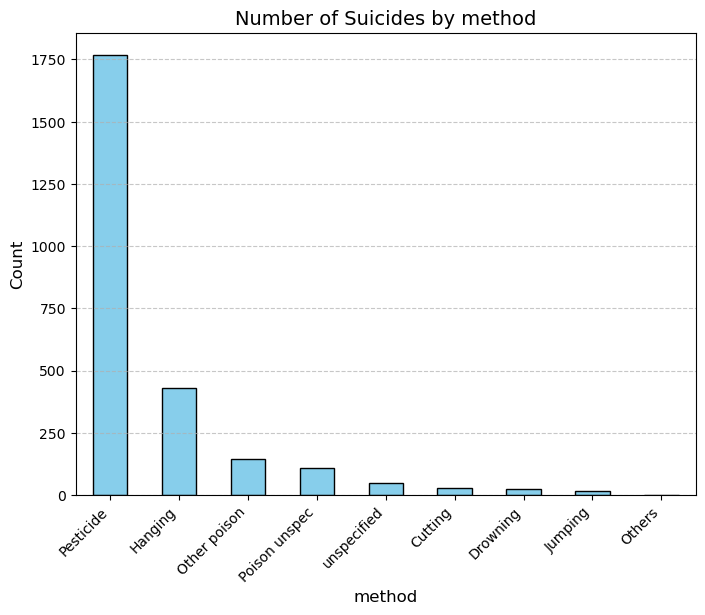

In [21]:
import matplotlib.pyplot as plt

# Reload the raw dataset (before encoding)
df_raw = pd.read_csv(r"E:\MS Data Science\Machine Learning\Home Work\SuicideChina.csv")

# Check the column name (in case it's different like 'Suicide_Method')
print("Columns:", df_raw.columns.tolist())

# If column is named something else, adjust 'method' below accordingly
plt.figure(figsize=(8, 6))
df_raw['method'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Number of Suicides by method", fontsize=14)
plt.xlabel("method", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Initialize KNN Classifier

In [22]:
# Step 4(a): Initialize KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN with 5 neighbors (you can tune this value later)
knn = KNeighborsClassifier(n_neighbors=5)

print("✅ KNN classifier initialized successfully!")


✅ KNN classifier initialized successfully!


## Initialize Logistic Regression Classifier

In [23]:
# Step 4(b): Initialize Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)

print("✅ Logistic Regression classifier initialized successfully!")


✅ Logistic Regression classifier initialized successfully!


## Build feature set (X) and labels (y)

In [24]:
# Step 5: Build feature set (X) and labels (y)

# Separate features and target
X = df.drop('Died', axis=1)
y = df['Died']

print("✅ Feature set and labels created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)


✅ Feature set and labels created successfully!
X shape: (2571, 19)
y shape: (2571,)


In [34]:
from sklearn.preprocessing import StandardScaler

# Step 6: Ensure all features are numeric floats
X = X.apply(pd.to_numeric, errors='coerce')  # Convert all to numeric, turn non-numeric into NaN

# Check if any NaNs appeared after conversion
print("Number of NaN values after conversion:", X.isna().sum().sum())

# Fill any NaNs (if any) with the column mean to avoid issues
X = X.fillna(X.mean())

# Now standardize the feature set
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ All features converted to float and standardized successfully!")
print("Feature matrix shape:", X_scaled.shape)


Number of NaN values after conversion: 5142
✅ All features converted to float and standardized successfully!
Feature matrix shape: (2571, 19)


C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## Standardize the feature set

In [35]:
# Step 6: Standardize the feature set
scaler = StandardScaler()

# Apply scaling (fit on all numeric features)
X_scaled = scaler.fit_transform(X)

print("✅ Feature set standardized successfully!")
print("Shape of standardized feature matrix:", X_scaled.shape)


✅ Feature set standardized successfully!
Shape of standardized feature matrix: (2571, 19)


C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## Split into train and test sets

In [36]:
from sklearn.model_selection import train_test_split

# Step 7: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3,       # 30% for testing
    random_state=42,     # for reproducibility
    stratify=y           # keeps class ratio same in train/test
)

print("✅ Data split completed successfully!")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


✅ Data split completed successfully!
Training set size: 1799
Testing set size: 772


In [38]:
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter

# Step 8 (Fixed): Handle NaNs before SMOTE
# Replace any remaining NaN values with column means
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Check for NaNs again
print("Any NaN left in training data:", np.isnan(X_train).any())

# Now apply SMOTE safely
print("Class distribution before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE:", Counter(y_train_res))
print("✅ SMOTE applied successfully after imputing missing values!")


C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: [1 6]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\Users\IQ COMPUTER\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: [1 6]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Any NaN left in training data: False
Class distribution before SMOTE: Counter({0: 920, 1: 879})
Class distribution after SMOTE: Counter({1: 920, 0: 920})
✅ SMOTE applied successfully after imputing missing values!


In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Initialize classifiers
knn = KNeighborsClassifier(n_neighbors=5)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train KNN
knn.fit(X_train_res, y_train_res)
print("✅ KNN model trained successfully!")

# Train Logistic Regression
log_reg.fit(X_train_res, y_train_res)
print("✅ Logistic Regression model trained successfully!")


✅ KNN model trained successfully!
✅ Logistic Regression model trained successfully!


## Predict on the Test Set

In [40]:
# Step 10: Predict on the test set
y_pred_knn = knn.predict(X_test)
y_pred_log = log_reg.predict(X_test)

print("✅ Predictions generated successfully!")
print("KNN predictions sample:", y_pred_knn[:10])
print("Logistic Regression predictions sample:", y_pred_log[:10])


✅ Predictions generated successfully!
KNN predictions sample: [1 0 0 0 1 0 0 1 0 0]
Logistic Regression predictions sample: [1 1 0 0 1 0 1 1 0 0]


## Model Evaluation

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Step 11a: Accuracy, Precision, and Recall for KNN
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)

# Step 11b: Accuracy, Precision, and Recall for Logistic Regression
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)

# Print results
print("🔹 KNN Classifier:")
print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall: {rec_knn:.4f}\n")

print("🔹 Logistic Regression Classifier:")
print(f"Accuracy: {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall: {rec_log:.4f}")


🔹 KNN Classifier:
Accuracy: 0.7422
Precision: 0.7587
Recall: 0.6923

🔹 Logistic Regression Classifier:
Accuracy: 0.7642
Precision: 0.7546
Recall: 0.7666


##  Confusion Matrix for Both Models



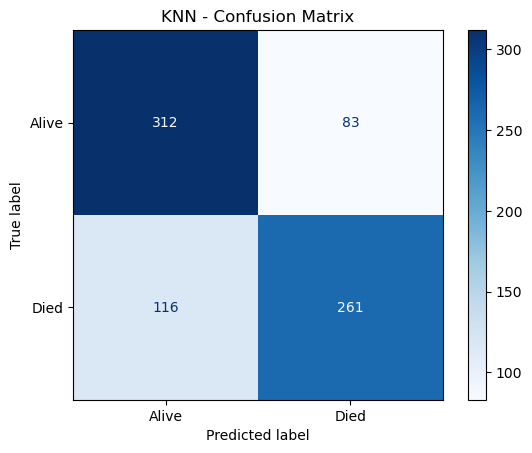

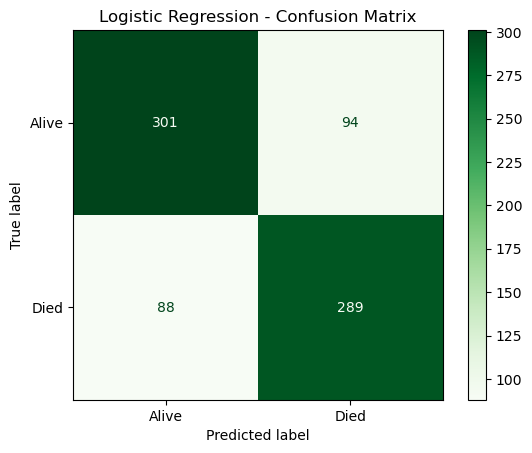

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 12: Confusion matrices
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_log = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix for KNN
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Alive", "Died"])
disp_knn.plot(cmap='Blues')
plt.title("KNN - Confusion Matrix")
plt.show()

# Plot confusion matrix for Logistic Regression
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Alive", "Died"])
disp_log.plot(cmap='Greens')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


